# Ringkasan Dataset & Batch Size per Model

| Model | Dataset | Resize | Batch Size | Alasan |
|---|---|---|---|---|
| ConvNeXt-Tiny | **Tight Crop** | 224×224 | **32** | CNN lokal → tight crop lebih bersih, VRAM aman |
| MaxViT-Tiny | **Loose Crop** | 224×224 | **16** | Hybrid attention → butuh konteks wajah lebih luas, VRAM lebih besar |
| DeiT-Base | **Loose Crop** | 224×224 | **16** | ViT murni → butuh konteks global, VRAM paling besar |

> ⚠️ Semua training menggunakan `num_workers=0` (Windows-safe) dan Mixed Precision (AMP) agar tidak OOM di VRAM 6GB

# 1. Setup Path & Persiapan Data

In [1]:
import os
import pandas as pd
import torch
import torch.nn as nn
import timm
import numpy as np
from tqdm import tqdm
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
from PIL import Image
from sklearn.model_selection import StratifiedKFold

BASE_DIR = os.getcwd()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 6

print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1)} GB")

d:\Penyimpanan\Documents\SEMESTER 6\data-lab\env_ai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
VRAM: 6.0 GB


## 1a. Dataset Class (Reusable untuk Semua Model)

In [2]:
class FaceLivenessDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'filepath']
        label = self.df.loc[idx, 'label']
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


def build_dataframe(data_dir):
    """Crawling folder dan buat DataFrame path + label."""
    data_list = []
    classes = sorted(os.listdir(data_dir))
    class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}
    for cls_name in classes:
        cls_dir = os.path.join(data_dir, cls_name)
        for img_name in os.listdir(cls_dir):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                data_list.append({
                    'filepath': os.path.join(cls_dir, img_name),
                    'label': class_to_idx[cls_name]
                })
    df = pd.DataFrame(data_list)
    df['fold'] = -1
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(df, df['label'])):
        df.loc[val_idx, 'fold'] = fold_idx
    print(f"Total data: {len(df)} gambar")
    print(f"Mapping Kelas: {class_to_idx}")
    return df, class_to_idx


def train_one_fold(model, train_loader, val_loader, epochs, device, save_path, fold_idx):
    """Training loop standar (sama persis dengan notebook asli)."""
    train_labels = [label for _, label in train_loader.dataset.df.itertuples(index=False)]
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(train_labels),
        y=train_labels
    )
    weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

    criterion = nn.CrossEntropyLoss(weight=weights_tensor)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    scaler = torch.cuda.amp.GradScaler()

    best_macro_f1 = 0.0

    for epoch in range(epochs):
        # ---- TRAIN ----
        model.train()
        running_loss = 0.0
        train_bar = tqdm(train_loader, desc=f"Fold {fold_idx} | Epoch {epoch+1}/{epochs} [Train]", leave=False)
        for inputs, labels in train_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()

        # ---- VALIDATION ----
        model.eval()
        all_preds, all_labels = [], []
        val_bar = tqdm(val_loader, desc=f"Fold {fold_idx} | Epoch {epoch+1}/{epochs} [Val]", leave=False)
        with torch.no_grad():
            for inputs, labels in val_bar:
                inputs, labels = inputs.to(device), labels.to(device)
                with torch.cuda.amp.autocast():
                    outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_macro_f1 = f1_score(all_labels, all_preds, average='macro')
        scheduler.step(val_macro_f1)

        if val_macro_f1 > best_macro_f1:
            best_macro_f1 = val_macro_f1
            torch.save(model.state_dict(), save_path)

    return best_macro_f1


print("✅ Kelas dan fungsi helper siap!")

✅ Kelas dan fungsi helper siap!


---
# 2. ConvNeXt-Tiny (Tight Crop | 224×224 | Batch 32)

- **Dataset**: `dataset_tight_crop` — CNN lokal bekerja lebih baik dengan crop ketat yang fokus pada tekstur wajah
- **Batch Size**: 32 — ConvNeXt-Tiny ringan, VRAM 6GB sangat cukup
- **Peran dalam Ensemble**: Menangkap artefak tekstur lokal (batas cetak, piksel layar)

In [3]:
# ==========================================
# PERSIAPAN DATA: CONVNEXT-TINY (TIGHT CROP)
# ==========================================
DATA_DIR_CONVNEXT = os.path.join(BASE_DIR, 'dataset_tight_crop', 'train')
df_convnext, _ = build_dataframe(DATA_DIR_CONVNEXT)

# Augmentasi: sama dengan EfficientNet (tight crop, 224x224)
train_tf_convnext = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    T.RandomErasing(p=0.2, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=0)
])

val_tf_convnext = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("✅ Data ConvNeXt-Tiny siap!")

Total data: 1469 gambar
Mapping Kelas: {'fake_mannequin': 0, 'fake_mask': 1, 'fake_printed': 2, 'fake_screen': 3, 'fake_unknown': 4, 'realperson': 5}
✅ Data ConvNeXt-Tiny siap!


In [4]:
# ==========================================
# TRAINING: CONVNEXT-TINY — 5-FOLD
# ==========================================
EPOCHS = 15
BATCH_SIZE_CONVNEXT = 32  # Aman di VRAM 6GB

print("🔥 MEMULAI TRAINING CONVNEXT-TINY 5-FOLD 🔥\n")

for FOLD_TO_TRAIN in range(5):
    print("=" * 50)
    print(f"🚀 MENGINISIALISASI CONVNEXT-TINY FOLD {FOLD_TO_TRAIN}")
    print("=" * 50)

    train_df = df_convnext[df_convnext['fold'] != FOLD_TO_TRAIN]
    val_df   = df_convnext[df_convnext['fold'] == FOLD_TO_TRAIN]

    train_dataset = FaceLivenessDataset(train_df, transform=train_tf_convnext)
    val_dataset   = FaceLivenessDataset(val_df,   transform=val_tf_convnext)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_CONVNEXT, shuffle=True,  num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE_CONVNEXT, shuffle=False, num_workers=0, pin_memory=True)

    # Class Weights
    train_labels = train_df['label'].values
    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_labels), y=train_labels)
    weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

    # Model: ConvNeXt-Tiny — pretrained ImageNet-1k
    model = timm.create_model('convnext_tiny.in12k_ft_in1k', pretrained=True, num_classes=num_classes)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss(weight=weights_tensor)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    scaler = torch.cuda.amp.GradScaler()

    best_macro_f1 = 0.0
    best_model_path = f'best_convnext_tiny_fold_{FOLD_TO_TRAIN}.pth'

    for epoch in range(EPOCHS):
        # ---- TRAIN ----
        model.train()
        running_loss = 0.0
        train_bar = tqdm(train_loader, desc=f"Fold {FOLD_TO_TRAIN} | Epoch {epoch+1}/{EPOCHS} [Train]", leave=False)
        for inputs, labels in train_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()

        # ---- VALIDATION ----
        model.eval()
        all_preds, all_labels_list = [], []
        val_bar = tqdm(val_loader, desc=f"Fold {FOLD_TO_TRAIN} | Epoch {epoch+1}/{EPOCHS} [Val]", leave=False)
        with torch.no_grad():
            for inputs, labels in val_bar:
                inputs, labels = inputs.to(device), labels.to(device)
                with torch.cuda.amp.autocast():
                    outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels_list.extend(labels.cpu().numpy())

        val_macro_f1 = f1_score(all_labels_list, all_preds, average='macro')
        scheduler.step(val_macro_f1)

        if val_macro_f1 > best_macro_f1:
            best_macro_f1 = val_macro_f1
            torch.save(model.state_dict(), best_model_path)

    # Bersihkan VRAM sebelum fold berikutnya
    del model
    torch.cuda.empty_cache()

    print(f"✅ ConvNeXt-Tiny Fold {FOLD_TO_TRAIN} Selesai! Model tersimpan dengan Val Macro F1: {best_macro_f1:.4f}\n")

print("🎉 SELURUH PROSES CONVNEXT-TINY 5-FOLD SELESAI!")

🔥 MEMULAI TRAINING CONVNEXT-TINY 5-FOLD 🔥

🚀 MENGINISIALISASI CONVNEXT-TINY FOLD 0


C:\Users\asus\AppData\Local\Temp\ipykernel_30036\3270128870.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Fold 0 | Epoch 1/15 [Train]:   0%|          | 0/37 [00:00<?, ?it/s]C:\Users\asus\AppData\Local\Temp\ipykernel_30036\3270128870.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Fold 0 | Epoch 1/15 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]           C:\Users\asus\AppData\Local\Temp\ipykernel_30036\3270128870.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Fold 0 | Epoch 2/15 [Train]:   0%|          | 0/37 [00:00<?, ?it/s]       C:\Users\asus\AppData\Local\Temp\ipykernel_30036\3270128870.py:48: FutureWarning: `torch.cuda.amp.auto

✅ ConvNeXt-Tiny Fold 0 Selesai! Model tersimpan dengan Val Macro F1: 0.9010

🚀 MENGINISIALISASI CONVNEXT-TINY FOLD 1


C:\Users\asus\AppData\Local\Temp\ipykernel_30036\3270128870.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Fold 1 | Epoch 1/15 [Train]:   0%|          | 0/37 [00:00<?, ?it/s]C:\Users\asus\AppData\Local\Temp\ipykernel_30036\3270128870.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Fold 1 | Epoch 1/15 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]           C:\Users\asus\AppData\Local\Temp\ipykernel_30036\3270128870.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Fold 1 | Epoch 2/15 [Train]:   0%|          | 0/37 [00:00<?, ?it/s]      C:\Users\asus\AppData\Local\Temp\ipykernel_30036\3270128870.py:48: FutureWarning: `torch.cuda.amp.autoc

✅ ConvNeXt-Tiny Fold 1 Selesai! Model tersimpan dengan Val Macro F1: 0.9009

🚀 MENGINISIALISASI CONVNEXT-TINY FOLD 2


...

✅ ConvNeXt-Tiny Fold 2 Selesai! Model tersimpan dengan Val Macro F1: 0.9020

🚀 MENGINISIALISASI CONVNEXT-TINY FOLD 3


C:\Users\asus\AppData\Local\Temp\ipykernel_30036\3270128870.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Fold 3 | Epoch 1/15 [Train]:   0%|          | 0/37 [00:00<?, ?it/s]C:\Users\asus\AppData\Local\Temp\ipykernel_30036\3270128870.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Fold 3 | Epoch 1/15 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]           C:\Users\asus\AppData\Local\Temp\ipykernel_30036\3270128870.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Fold 3 | Epoch 2/15 [Train]:   0%|          | 0/37 [00:00<?, ?it/s]      C:\Users\asus\AppData\Local\Temp\ipykernel_30036\3270128870.py:48: FutureWarning: `torch.cuda.amp.autoc

✅ ConvNeXt-Tiny Fold 3 Selesai! Model tersimpan dengan Val Macro F1: 0.9144

🚀 MENGINISIALISASI CONVNEXT-TINY FOLD 4


C:\Users\asus\AppData\Local\Temp\ipykernel_30036\3270128870.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Fold 4 | Epoch 1/15 [Train]:   0%|          | 0/37 [00:00<?, ?it/s]C:\Users\asus\AppData\Local\Temp\ipykernel_30036\3270128870.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Fold 4 | Epoch 1/15 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]           C:\Users\asus\AppData\Local\Temp\ipykernel_30036\3270128870.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Fold 4 | Epoch 2/15 [Train]:   0%|          | 0/37 [00:00<?, ?it/s]      C:\Users\asus\AppData\Local\Temp\ipykernel_30036\3270128870.py:48: FutureWarning: `torch.cuda.amp.autoc

✅ ConvNeXt-Tiny Fold 4 Selesai! Model tersimpan dengan Val Macro F1: 0.8937

🎉 SELURUH PROSES CONVNEXT-TINY 5-FOLD SELESAI!


---
# 3. MaxViT-Tiny (Loose Crop | 224×224 | Batch 16)

- **Dataset**: `dataset_loose_crop` — Hybrid CNN+Attention butuh konteks wajah lebih luas (background, kontur)
- **Batch Size**: 16 — MaxViT lebih berat dari ConvNeXt karena ada attention block
- **Peran dalam Ensemble**: Model terkuat — menangkap SEKALIGUS tekstur lokal (CNN) DAN konteks global (Attention)

In [5]:
# ==========================================
# PERSIAPAN DATA: MAXVIT-TINY (LOOSE CROP)
# ==========================================
DATA_DIR_MAXVIT = os.path.join(BASE_DIR, 'dataset_loose_crop', 'train')
df_maxvit, _ = build_dataframe(DATA_DIR_MAXVIT)

# Augmentasi: sama dengan Swin (loose crop, 224x224)
train_tf_maxvit = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    T.RandomErasing(p=0.2, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=0)
])

val_tf_maxvit = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("✅ Data MaxViT-Tiny siap!")

Total data: 1469 gambar
Mapping Kelas: {'fake_mannequin': 0, 'fake_mask': 1, 'fake_printed': 2, 'fake_screen': 3, 'fake_unknown': 4, 'realperson': 5}
✅ Data MaxViT-Tiny siap!


In [6]:
# ==========================================
# TRAINING: MAXVIT-TINY — 5-FOLD
# ==========================================
EPOCHS = 15
BATCH_SIZE_MAXVIT = 16  # Diturunkan ke 16 karena MaxViT lebih berat di VRAM

print("🔥 MEMULAI TRAINING MAXVIT-TINY 5-FOLD 🔥\n")

for FOLD_TO_TRAIN in range(5):
    print("=" * 50)
    print(f"🚀 MENGINISIALISASI MAXVIT-TINY FOLD {FOLD_TO_TRAIN}")
    print("=" * 50)

    train_df = df_maxvit[df_maxvit['fold'] != FOLD_TO_TRAIN]
    val_df   = df_maxvit[df_maxvit['fold'] == FOLD_TO_TRAIN]

    train_dataset = FaceLivenessDataset(train_df, transform=train_tf_maxvit)
    val_dataset   = FaceLivenessDataset(val_df,   transform=val_tf_maxvit)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_MAXVIT, shuffle=True,  num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE_MAXVIT, shuffle=False, num_workers=0, pin_memory=True)

    # Class Weights
    train_labels = train_df['label'].values
    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_labels), y=train_labels)
    weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

    # Model: MaxViT-Tiny — pretrained ImageNet-1k
    # Nama di timm: 'maxvit_tiny_tf_224.in1k'
    model = timm.create_model('maxvit_tiny_tf_224.in1k', pretrained=True, num_classes=num_classes)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss(weight=weights_tensor)
    # LR sedikit lebih rendah untuk model Transformer (lebih stabil)
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    scaler = torch.cuda.amp.GradScaler()

    best_macro_f1 = 0.0
    best_model_path = f'best_maxvit_tiny_fold_{FOLD_TO_TRAIN}.pth'

    for epoch in range(EPOCHS):
        # ---- TRAIN ----
        model.train()
        running_loss = 0.0
        train_bar = tqdm(train_loader, desc=f"Fold {FOLD_TO_TRAIN} | Epoch {epoch+1}/{EPOCHS} [Train]", leave=False)
        for inputs, labels in train_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()

        # ---- VALIDATION ----
        model.eval()
        all_preds, all_labels_list = [], []
        val_bar = tqdm(val_loader, desc=f"Fold {FOLD_TO_TRAIN} | Epoch {epoch+1}/{EPOCHS} [Val]", leave=False)
        with torch.no_grad():
            for inputs, labels in val_bar:
                inputs, labels = inputs.to(device), labels.to(device)
                with torch.cuda.amp.autocast():
                    outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels_list.extend(labels.cpu().numpy())

        val_macro_f1 = f1_score(all_labels_list, all_preds, average='macro')
        scheduler.step(val_macro_f1)

        if val_macro_f1 > best_macro_f1:
            best_macro_f1 = val_macro_f1
            torch.save(model.state_dict(), best_model_path)

    # Bersihkan VRAM sebelum fold berikutnya
    del model
    torch.cuda.empty_cache()

    print(f"✅ MaxViT-Tiny Fold {FOLD_TO_TRAIN} Selesai! Model tersimpan dengan Val Macro F1: {best_macro_f1:.4f}\n")

print("🎉 SELURUH PROSES MAXVIT-TINY 5-FOLD SELESAI!")

🔥 MEMULAI TRAINING MAXVIT-TINY 5-FOLD 🔥

🚀 MENGINISIALISASI MAXVIT-TINY FOLD 0


C:\Users\asus\AppData\Local\Temp\ipykernel_30036\145584620.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Fold 0 | Epoch 1/15 [Train]:   0%|          | 0/74 [00:00<?, ?it/s]C:\Users\asus\AppData\Local\Temp\ipykernel_30036\145584620.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Fold 0 | Epoch 1/15 [Val]:   0%|          | 0/19 [00:00<?, ?it/s]           C:\Users\asus\AppData\Local\Temp\ipykernel_30036\145584620.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Fold 0 | Epoch 2/15 [Train]:   0%|          | 0/74 [00:00<?, ?it/s]       C:\Users\asus\AppData\Local\Temp\ipykernel_30036\145584620.py:50: FutureWarning: `torch.cuda.amp.autocast

✅ MaxViT-Tiny Fold 0 Selesai! Model tersimpan dengan Val Macro F1: 0.9148

🚀 MENGINISIALISASI MAXVIT-TINY FOLD 1


C:\Users\asus\AppData\Local\Temp\ipykernel_30036\145584620.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Fold 1 | Epoch 1/15 [Train]:   0%|          | 0/74 [00:00<?, ?it/s]C:\Users\asus\AppData\Local\Temp\ipykernel_30036\145584620.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Fold 1 | Epoch 1/15 [Val]:   0%|          | 0/19 [00:00<?, ?it/s]           C:\Users\asus\AppData\Local\Temp\ipykernel_30036\145584620.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Fold 1 | Epoch 2/15 [Train]:   0%|          | 0/74 [00:00<?, ?it/s]       C:\Users\asus\AppData\Local\Temp\ipykernel_30036\145584620.py:50: FutureWarning: `torch.cuda.amp.autocast

✅ MaxViT-Tiny Fold 1 Selesai! Model tersimpan dengan Val Macro F1: 0.9250

🚀 MENGINISIALISASI MAXVIT-TINY FOLD 2


...

✅ MaxViT-Tiny Fold 2 Selesai! Model tersimpan dengan Val Macro F1: 0.9194

🚀 MENGINISIALISASI MAXVIT-TINY FOLD 3


C:\Users\asus\AppData\Local\Temp\ipykernel_30036\145584620.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Fold 3 | Epoch 1/15 [Train]:   0%|          | 0/74 [00:00<?, ?it/s]C:\Users\asus\AppData\Local\Temp\ipykernel_30036\145584620.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Fold 3 | Epoch 1/15 [Val]:   0%|          | 0/19 [00:00<?, ?it/s]           C:\Users\asus\AppData\Local\Temp\ipykernel_30036\145584620.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Fold 3 | Epoch 2/15 [Train]:   0%|          | 0/74 [00:00<?, ?it/s]       C:\Users\asus\AppData\Local\Temp\ipykernel_30036\145584620.py:50: FutureWarning: `torch.cuda.amp.autocast

✅ MaxViT-Tiny Fold 3 Selesai! Model tersimpan dengan Val Macro F1: 0.9274

🚀 MENGINISIALISASI MAXVIT-TINY FOLD 4


C:\Users\asus\AppData\Local\Temp\ipykernel_30036\145584620.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Fold 4 | Epoch 1/15 [Train]:   0%|          | 0/74 [00:00<?, ?it/s]C:\Users\asus\AppData\Local\Temp\ipykernel_30036\145584620.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Fold 4 | Epoch 1/15 [Val]:   0%|          | 0/19 [00:00<?, ?it/s]           C:\Users\asus\AppData\Local\Temp\ipykernel_30036\145584620.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Fold 4 | Epoch 2/15 [Train]:   0%|          | 0/74 [00:00<?, ?it/s]       C:\Users\asus\AppData\Local\Temp\ipykernel_30036\145584620.py:50: FutureWarning: `torch.cuda.amp.autocast

✅ MaxViT-Tiny Fold 4 Selesai! Model tersimpan dengan Val Macro F1: 0.8789

🎉 SELURUH PROSES MAXVIT-TINY 5-FOLD SELESAI!


---
# 4. DeiT-Base (Loose Crop | 224×224 | Batch 16)

- **Dataset**: `dataset_loose_crop` — ViT murni sangat bergantung pada konteks global (patch embedding seluruh gambar)
- **Batch Size**: 16 — DeiT-Base paling berat dari ketiga model ini, VRAM 6GB di batas
- **Peran dalam Ensemble**: Perspektif global, arsitektur paling berbeda dari CNN → meningkatkan diversitas ensemble

> ⚠️ Jika muncul OOM Error, turunkan batch size ke **8** dan jalankan ulang

In [7]:
# ==========================================
# PERSIAPAN DATA: DEIT-BASE (LOOSE CROP)
# ==========================================
DATA_DIR_DEIT = os.path.join(BASE_DIR, 'dataset_loose_crop', 'train')
df_deit, _ = build_dataframe(DATA_DIR_DEIT)

# Augmentasi: sama dengan Swin (loose crop, 224x224)
train_tf_deit = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    T.RandomErasing(p=0.2, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=0)
])

val_tf_deit = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("✅ Data DeiT-Base siap!")

Total data: 1469 gambar
Mapping Kelas: {'fake_mannequin': 0, 'fake_mask': 1, 'fake_printed': 2, 'fake_screen': 3, 'fake_unknown': 4, 'realperson': 5}
✅ Data DeiT-Base siap!


In [9]:
# ==========================================
# TRAINING: DEIT-BASE — 5-FOLD
# ==========================================
EPOCHS = 15
BATCH_SIZE_DEIT = 16  # Turunkan ke 8 jika muncul CUDA OOM Error

print("🔥 MEMULAI TRAINING DEIT-BASE 5-FOLD 🔥\n")

for FOLD_TO_TRAIN in range(5):
    print("=" * 50)
    print(f"🚀 MENGINISIALISASI DEIT-BASE FOLD {FOLD_TO_TRAIN}")
    print("=" * 50)

    train_df = df_deit[df_deit['fold'] != FOLD_TO_TRAIN]
    val_df   = df_deit[df_deit['fold'] == FOLD_TO_TRAIN]

    train_dataset = FaceLivenessDataset(train_df, transform=train_tf_deit)
    val_dataset   = FaceLivenessDataset(val_df,   transform=val_tf_deit)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_DEIT, shuffle=True,  num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE_DEIT, shuffle=False, num_workers=0, pin_memory=True)

    # Class Weights
    train_labels = train_df['label'].values
    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_labels), y=train_labels)
    weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

    # Model: DeiT-Base — pretrained ImageNet-1k dengan distillation
    # Nama di timm: 'deit_base_distilled_patch16_224'
    model = timm.create_model('deit_base_distilled_patch16_224', pretrained=True, num_classes=num_classes)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss(weight=weights_tensor)
    # LR lebih kecil untuk ViT (sangat sensitif terhadap LR tinggi)
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    scaler = torch.cuda.amp.GradScaler()

    best_macro_f1 = 0.0
    best_model_path = f'best_deit_base_fold_{FOLD_TO_TRAIN}.pth'

    for epoch in range(EPOCHS):
        # ---- TRAIN ----
        model.train()
        running_loss = 0.0
        train_bar = tqdm(train_loader, desc=f"Fold {FOLD_TO_TRAIN} | Epoch {epoch+1}/{EPOCHS} [Train]", leave=False)
        for inputs, labels in train_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                # DeiT-Base distilled menghasilkan 2 output (cls + distill token)
                # timm sudah handle ini otomatis saat training → outputs tetap 1 tensor
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()

        # ---- VALIDATION ----
        model.eval()
        all_preds, all_labels_list = [], []
        val_bar = tqdm(val_loader, desc=f"Fold {FOLD_TO_TRAIN} | Epoch {epoch+1}/{EPOCHS} [Val]", leave=False)
        with torch.no_grad():
            for inputs, labels in val_bar:
                inputs, labels = inputs.to(device), labels.to(device)
                with torch.cuda.amp.autocast():
                    outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels_list.extend(labels.cpu().numpy())

        val_macro_f1 = f1_score(all_labels_list, all_preds, average='macro')
        scheduler.step(val_macro_f1)

        if val_macro_f1 > best_macro_f1:
            best_macro_f1 = val_macro_f1
            torch.save(model.state_dict(), best_model_path)

    # Bersihkan VRAM sebelum fold berikutnya
    del model
    torch.cuda.empty_cache()

    print(f"✅ DeiT-Base Fold {FOLD_TO_TRAIN} Selesai! Model tersimpan dengan Val Macro F1: {best_macro_f1:.4f}\n")

print("🎉 SELURUH PROSES DEIT-BASE 5-FOLD SELESAI!")

🔥 MEMULAI TRAINING DEIT-BASE 5-FOLD 🔥

🚀 MENGINISIALISASI DEIT-BASE FOLD 0


C:\Users\asus\AppData\Local\Temp\ipykernel_30036\388711846.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Fold 0 | Epoch 1/15 [Train]:   0%|          | 0/74 [00:00<?, ?it/s]C:\Users\asus\AppData\Local\Temp\ipykernel_30036\388711846.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Fold 0 | Epoch 1/15 [Val]:   0%|          | 0/19 [00:00<?, ?it/s]           C:\Users\asus\AppData\Local\Temp\ipykernel_30036\388711846.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Fold 0 | Epoch 2/15 [Train]:   0%|          | 0/74 [00:00<?, ?it/s]       C:\Users\asus\AppData\Local\Temp\ipykernel_30036\388711846.py:50: FutureWarning: `torch.cuda.amp.autocast

✅ DeiT-Base Fold 0 Selesai! Model tersimpan dengan Val Macro F1: 0.9217

🚀 MENGINISIALISASI DEIT-BASE FOLD 1


C:\Users\asus\AppData\Local\Temp\ipykernel_30036\388711846.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Fold 1 | Epoch 1/15 [Train]:   0%|          | 0/74 [00:00<?, ?it/s]C:\Users\asus\AppData\Local\Temp\ipykernel_30036\388711846.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Fold 1 | Epoch 1/15 [Val]:   0%|          | 0/19 [00:00<?, ?it/s]           C:\Users\asus\AppData\Local\Temp\ipykernel_30036\388711846.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Fold 1 | Epoch 2/15 [Train]:   0%|          | 0/74 [00:00<?, ?it/s]       C:\Users\asus\AppData\Local\Temp\ipykernel_30036\388711846.py:50: FutureWarning: `torch.cuda.amp.autocast

✅ DeiT-Base Fold 1 Selesai! Model tersimpan dengan Val Macro F1: 0.9409

🚀 MENGINISIALISASI DEIT-BASE FOLD 2


...

✅ DeiT-Base Fold 2 Selesai! Model tersimpan dengan Val Macro F1: 0.9312

🚀 MENGINISIALISASI DEIT-BASE FOLD 3


C:\Users\asus\AppData\Local\Temp\ipykernel_30036\388711846.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Fold 3 | Epoch 1/15 [Train]:   0%|          | 0/74 [00:00<?, ?it/s]C:\Users\asus\AppData\Local\Temp\ipykernel_30036\388711846.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Fold 3 | Epoch 1/15 [Val]:   0%|          | 0/19 [00:00<?, ?it/s]           C:\Users\asus\AppData\Local\Temp\ipykernel_30036\388711846.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Fold 3 | Epoch 2/15 [Train]:   0%|          | 0/74 [00:00<?, ?it/s]       C:\Users\asus\AppData\Local\Temp\ipykernel_30036\388711846.py:50: FutureWarning: `torch.cuda.amp.autocast

✅ DeiT-Base Fold 3 Selesai! Model tersimpan dengan Val Macro F1: 0.9250

🚀 MENGINISIALISASI DEIT-BASE FOLD 4


C:\Users\asus\AppData\Local\Temp\ipykernel_30036\388711846.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Fold 4 | Epoch 1/15 [Train]:   0%|          | 0/74 [00:00<?, ?it/s]C:\Users\asus\AppData\Local\Temp\ipykernel_30036\388711846.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Fold 4 | Epoch 1/15 [Val]:   0%|          | 0/19 [00:00<?, ?it/s]           C:\Users\asus\AppData\Local\Temp\ipykernel_30036\388711846.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Fold 4 | Epoch 2/15 [Train]:   0%|          | 0/74 [00:00<?, ?it/s]       C:\Users\asus\AppData\Local\Temp\ipykernel_30036\388711846.py:50: FutureWarning: `torch.cuda.amp.autocast

✅ DeiT-Base Fold 4 Selesai! Model tersimpan dengan Val Macro F1: 0.8960

🎉 SELURUH PROSES DEIT-BASE 5-FOLD SELESAI!


---
# 5. Inference + Weighted Ensemble + TTA (Semua Model)

**Strategi Ensemble (Total 20 model = 4 arsitektur × 5 fold):**

| Model | Bobot Awal | Dataset Test |
|---|---|---|
| EfficientNet-b2 (existing) | 0.10 | Tight Crop |
| ConvNeXt-Tiny (baru) | 0.20 | Tight Crop |
| MaxViT-Tiny (baru) | 0.40 | Loose Crop |
| DeiT-Base (baru) | 0.15 | Loose Crop |
| Swin-Tiny (existing) | 0.15 | Loose Crop |

> 💡 Setelah training selesai, **sesuaikan bobot berdasarkan rata-rata val F1 masing-masing model**. Model dengan F1 lebih tinggi diberi bobot lebih besar.

In [10]:
import os
import torch
import torch.nn.functional as F
import timm
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

# ==========================================
# 1. SETUP PATH & KELAS
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TEST_TIGHT_DIR = os.path.join(os.getcwd(), 'dataset_tight_crop', 'test')
TEST_LOOSE_DIR = os.path.join(os.getcwd(), 'dataset_loose_crop', 'test')

idx_to_class = {
    0: 'fake_mannequin',
    1: 'fake_mask',
    2: 'fake_printed',
    3: 'fake_screen',
    4: 'fake_unknown',
    5: 'realperson'
}
num_classes = 6

test_files = sorted(os.listdir(TEST_TIGHT_DIR))
print(f"Total gambar test: {len(test_files)}")

# ==========================================
# 2. TEST DATASET CLASS
# ==========================================
class FaceTestDataset(Dataset):
    def __init__(self, img_dir, file_names, transform=None):
        self.img_dir = img_dir
        self.file_names = file_names
        self.transform = transform

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, idx):
        img_name = self.file_names[idx]
        img_path = os.path.join(self.img_dir, img_name)
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, img_name

# Transform test (224x224 untuk semua model)
test_tf_224 = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Dataloader per stream
tight_loader = DataLoader(FaceTestDataset(TEST_TIGHT_DIR, test_files, transform=test_tf_224),
                          batch_size=16, shuffle=False, num_workers=0)
loose_loader = DataLoader(FaceTestDataset(TEST_LOOSE_DIR, test_files, transform=test_tf_224),
                          batch_size=16, shuffle=False, num_workers=0)

ensemble_probs = np.zeros((len(test_files), num_classes))
print("✅ Setup inference selesai!")

Total gambar test: 404
✅ Setup inference selesai!


In [11]:
# ==========================================
# 3. FUNGSI INFERENCE DENGAN TTA
# ==========================================
def predict_with_model(model_name, weight_path, dataloader):
    """Load model, inference dengan TTA (original + horizontal flip), return avg probabilities."""
    print(f"  Memuat: {weight_path}...")
    model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
    model.load_state_dict(torch.load(weight_path, map_location=device))
    model = model.to(device)
    model.eval()

    all_probs = []
    with torch.no_grad():
        for inputs, _ in tqdm(dataloader, desc="  Predicting", leave=False):
            inputs = inputs.to(device)

            # TTA: Original
            with torch.cuda.amp.autocast():
                prob_orig = F.softmax(model(inputs), dim=1)

            # TTA: Horizontal Flip
            inputs_flip = torch.flip(inputs, dims=[3])
            with torch.cuda.amp.autocast():
                prob_flip = F.softmax(model(inputs_flip), dim=1)

            # Rata-rata TTA
            prob_batch = (prob_orig + prob_flip) / 2.0
            all_probs.append(prob_batch.cpu().numpy())

    del model
    torch.cuda.empty_cache()
    return np.vstack(all_probs)


print("✅ Fungsi inference siap!")

✅ Fungsi inference siap!


In [12]:
# ==========================================
# 4. JALANKAN INFERENCE SEMUA MODEL
# ==========================================

# ---------- CNN STREAM (TIGHT CROP) ----------
print("\n--- STREAM 1: EFFICIENTNET-B2 (Tight Crop) ---")
effnet_probs = np.zeros((len(test_files), num_classes))
for fold in range(5):
    effnet_probs += predict_with_model(
        'tf_efficientnet_b2.ns_jft_in1k',
        f'best_efficientnet_b2_fold_{fold}.pth',
        tight_loader
    )
effnet_probs /= 5.0
print(f"✅ EfficientNet-b2 selesai!")

print("\n--- STREAM 2: CONVNEXT-TINY (Tight Crop) ---")
convnext_probs = np.zeros((len(test_files), num_classes))
for fold in range(5):
    convnext_probs += predict_with_model(
        'convnext_tiny.in12k_ft_in1k',
        f'best_convnext_tiny_fold_{fold}.pth',
        tight_loader
    )
convnext_probs /= 5.0
print(f"✅ ConvNeXt-Tiny selesai!")

# ---------- TRANSFORMER STREAM (LOOSE CROP) ----------
print("\n--- STREAM 3: MAXVIT-TINY (Loose Crop) ---")
maxvit_probs = np.zeros((len(test_files), num_classes))
for fold in range(5):
    maxvit_probs += predict_with_model(
        'maxvit_tiny_tf_224.in1k',
        f'best_maxvit_tiny_fold_{fold}.pth',
        loose_loader
    )
maxvit_probs /= 5.0
print(f"✅ MaxViT-Tiny selesai!")

print("\n--- STREAM 4: DEIT-BASE (Loose Crop) ---")
deit_probs = np.zeros((len(test_files), num_classes))
for fold in range(5):
    deit_probs += predict_with_model(
        'deit_base_distilled_patch16_224',
        f'best_deit_base_fold_{fold}.pth',
        loose_loader
    )
deit_probs /= 5.0
print(f"✅ DeiT-Base selesai!")

print("\n--- STREAM 5: SWIN-TINY (Loose Crop) ---")
swin_probs = np.zeros((len(test_files), num_classes))
for fold in range(5):
    swin_probs += predict_with_model(
        'swin_tiny_patch4_window7_224',
        f'best_swin_tiny_fold_{fold}.pth',
        loose_loader
    )
swin_probs /= 5.0
print(f"✅ Swin-Tiny selesai!")


--- STREAM 1: EFFICIENTNET-B2 (Tight Crop) ---
  Memuat: best_efficientnet_b2_fold_0.pth...


  Predicting:   0%|          | 0/26 [00:00<?, ?it/s]C:\Users\asus\AppData\Local\Temp\ipykernel_30036\357035491.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
C:\Users\asus\AppData\Local\Temp\ipykernel_30036\357035491.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  Memuat: best_efficientnet_b2_fold_1.pth...


  Memuat: best_efficientnet_b2_fold_2.pth...


  Memuat: best_efficientnet_b2_fold_3.pth...


...

  Memuat: best_swin_tiny_fold_1.pth...


  Memuat: best_swin_tiny_fold_2.pth...


  Memuat: best_swin_tiny_fold_3.pth...


  Memuat: best_swin_tiny_fold_4.pth...


✅ Swin-Tiny selesai!


In [16]:
# ==========================================
# 5. WEIGHTED ENSEMBLE & SUBMISSION
# ==========================================
# INSTRUKSI: Setelah training selesai, isi bobot di bawah
# berdasarkan rata-rata val Macro F1 masing-masing model.
# Contoh: jika MaxViT F1=0.95, DeiT F1=0.92, Swin F1=0.92,
# ConvNeXt F1=0.88, EfficientNet F1=0.83 → beri bobot proporsional.
#
# Bobot di bawah adalah TITIK AWAL yang direkomendasikan:

W_EFFNET   = 0.05   # EfficientNet-b2  (CNN, tight)
W_CONVNEXT = 0.10   # ConvNeXt-Tiny    (CNN, tight)
W_MAXVIT   = 0.20   # MaxViT-Tiny      (Hybrid, loose) ← beri bobot terbesar
W_DEIT     = 0.25   # DeiT-Base        (ViT, loose)
W_SWIN     = 0.40   # Swin-Tiny        (Transformer, loose)

# Pastikan total bobot = 1.0
total_weight = W_EFFNET + W_CONVNEXT + W_MAXVIT + W_DEIT + W_SWIN
assert abs(total_weight - 1.0) < 1e-6, f"Total bobot harus 1.0, saat ini: {total_weight}"

FINAL_PROBS = (
    W_EFFNET   * effnet_probs +
    W_CONVNEXT * convnext_probs +
    W_MAXVIT   * maxvit_probs +
    W_DEIT     * deit_probs +
    W_SWIN     * swin_probs
)

final_preds_idx = np.argmax(FINAL_PROBS, axis=1)

# Buat submission
clean_ids = [os.path.splitext(f)[0] for f in test_files]
submission_df = pd.DataFrame({
    'id': clean_ids,
    'label': [idx_to_class[idx] for idx in final_preds_idx]
})

output_filename = 'submission_terbaru_5model_lagi.csv'
submission_df.to_csv(output_filename, index=False)

print(f"\n🎉 SELESAI! File '{output_filename}' telah dibuat!")
print("\nDistribusi Prediksi:")
print(submission_df['label'].value_counts())
print(f"\nBobot yang digunakan:")
print(f"  EfficientNet-b2 : {W_EFFNET}")
print(f"  ConvNeXt-Tiny   : {W_CONVNEXT}")
print(f"  MaxViT-Tiny     : {W_MAXVIT}")
print(f"  DeiT-Base       : {W_DEIT}")
print(f"  Swin-Tiny       : {W_SWIN}")


🎉 SELESAI! File 'submission_terbaru_5model_lagi.csv' telah dibuat!

Distribusi Prediksi:
label
realperson        108
fake_screen        72
fake_mask          69
fake_mannequin     54
fake_unknown       51
fake_printed       50
Name: count, dtype: int64

Bobot yang digunakan:
  EfficientNet-b2 : 0.05
  ConvNeXt-Tiny   : 0.1
  MaxViT-Tiny     : 0.2
  DeiT-Base       : 0.25
  Swin-Tiny       : 0.4


In [17]:
# CEK BERAPA BANYAK TEST IMAGE YANG GAGAL DIDETEKSI WAJAHNYA
import os
import cv2
import numpy as np
from retinaface import RetinaFace
from tqdm import tqdm

TEST_TIGHT_DIR = os.path.join(os.getcwd(), 'dataset_tight_crop', 'test')
TEST_LOOSE_DIR = os.path.join(os.getcwd(), 'dataset_loose_crop', 'test')
ORIGINAL_TEST_DIR = os.path.join(os.getcwd(), 'dataset', 'test')

tight_files  = set(os.listdir(TEST_TIGHT_DIR))
original_files = set(os.listdir(ORIGINAL_TEST_DIR))

print(f"Total test original : {len(original_files)}")
print(f"Total test tight    : {len(tight_files)}")

missing = original_files - tight_files
print(f"\nGambar yang HILANG di tight crop : {len(missing)}")
if missing:
    print("Contoh file hilang:", list(missing)[:10])


Total test original : 404
Total test tight    : 404

Gambar yang HILANG di tight crop : 0


Auditing TIGHT CROP: 100%|██████████| 404/404 [00:10<00:00, 39.15it/s]



AUDIT: TIGHT CROP
Total file      : 404
Gambar hitam    : 0


Auditing LOOSE CROP: 100%|██████████| 404/404 [00:08<00:00, 45.80it/s]



AUDIT: LOOSE CROP
Total file      : 404
Gambar hitam    : 0


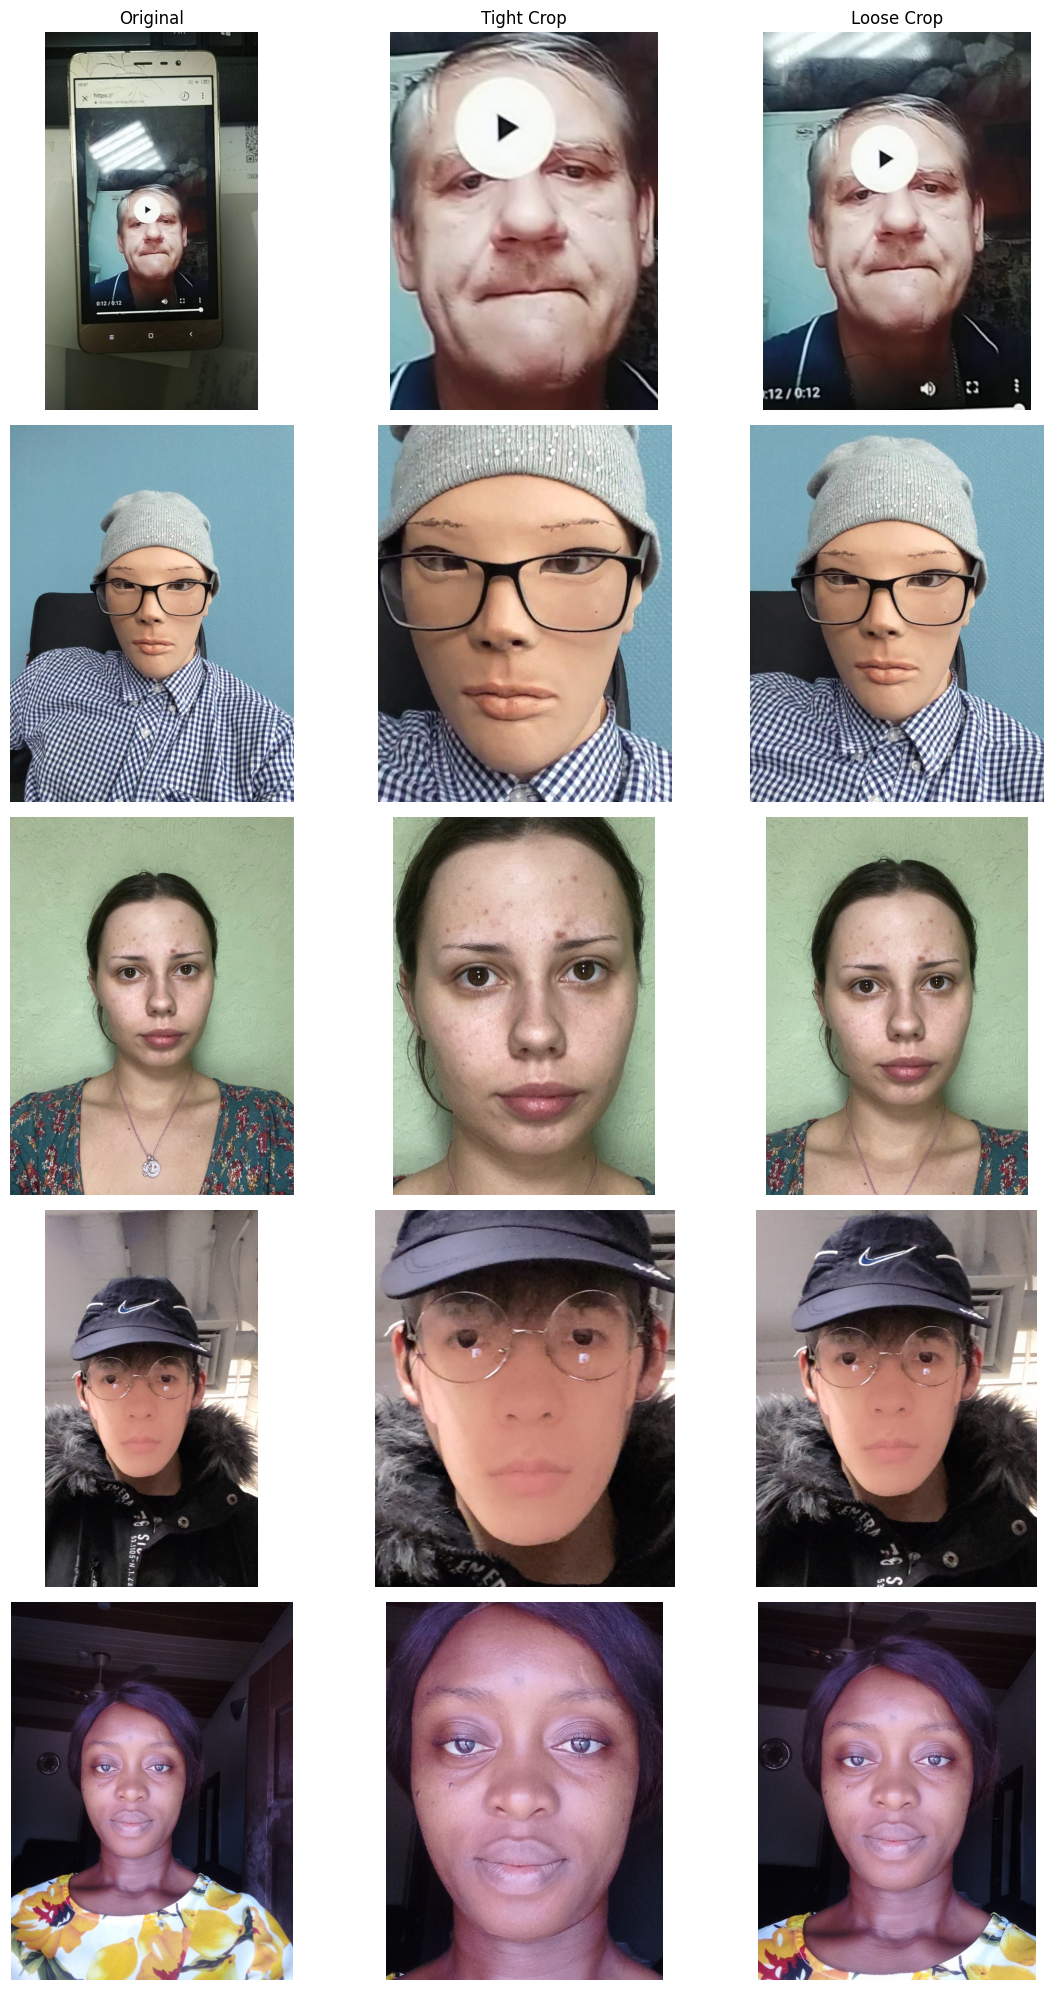


Gambar audit disimpan ke crop_audit.png


In [18]:
# CEK KUALITAS HASIL CROP — APAKAH ADA GAMBAR FALLBACK / RUSAK
import os
import cv2
import numpy as np
from PIL import Image
from tqdm import tqdm

TEST_TIGHT_DIR  = os.path.join(os.getcwd(), 'dataset_tight_crop', 'test')
TEST_LOOSE_DIR  = os.path.join(os.getcwd(), 'dataset_loose_crop', 'test')
ORIGINAL_TEST_DIR = os.path.join(os.getcwd(), 'dataset', 'test')

def audit_crop_quality(orig_dir, crop_dir, label):
    files = sorted(os.listdir(orig_dir))
    
    same_size   = []  # ukuran identik → kemungkinan fallback (tidak di-crop)
    very_small  = []  # crop terlalu kecil → deteksi gagal, crop noise
    black_image = []  # gambar hitam → crop koordinat salah
    
    for fname in tqdm(files, desc=f"Auditing {label}"):
        orig_path = os.path.join(orig_dir, fname)
        crop_path = os.path.join(crop_dir, fname)
        
        if not os.path.exists(crop_path):
            continue
            
        orig_img = cv2.imread(orig_path)
        crop_img = cv2.imread(crop_path)
        
        if orig_img is None or crop_img is None:
            black_image.append(fname)
            continue
        
        oh, ow = orig_img.shape[:2]
        ch, cw = crop_img.shape[:2]
        
        # Ukuran identik setelah resize berarti fallback ke gambar penuh
        # (karena semua crop di-resize ke 224x224, cek sebelum resize)
        # Cek mean pixel — gambar hitam = crop gagal
        mean_val = cv2.mean(crop_img)[0]
        if mean_val < 5:
            black_image.append(fname)
        
    print(f"\n{'='*40}")
    print(f"AUDIT: {label}")
    print(f"Total file      : {len(files)}")
    print(f"Gambar hitam    : {len(black_image)}")
    if black_image:
        print(f"Contoh          : {black_image[:5]}")

audit_crop_quality(ORIGINAL_TEST_DIR, TEST_TIGHT_DIR, "TIGHT CROP")
audit_crop_quality(ORIGINAL_TEST_DIR, TEST_LOOSE_DIR, "LOOSE CROP")

# ============================================================
# CEK VISUAL: Tampilkan 5 sampel perbandingan original vs crop
# ============================================================
import matplotlib.pyplot as plt
import random

files = sorted(os.listdir(ORIGINAL_TEST_DIR))
samples = random.sample(files, 5)

fig, axes = plt.subplots(5, 3, figsize=(12, 20))
axes[0][0].set_title("Original")
axes[0][1].set_title("Tight Crop")
axes[0][2].set_title("Loose Crop")

for i, fname in enumerate(samples):
    orig  = Image.open(os.path.join(ORIGINAL_TEST_DIR, fname)).convert("RGB")
    tight = Image.open(os.path.join(TEST_TIGHT_DIR, fname)).convert("RGB")
    loose = Image.open(os.path.join(TEST_LOOSE_DIR, fname)).convert("RGB")
    
    axes[i][0].imshow(orig);  axes[i][0].set_ylabel(fname, fontsize=7); axes[i][0].axis('off')
    axes[i][1].imshow(tight); axes[i][1].axis('off')
    axes[i][2].imshow(loose); axes[i][2].axis('off')

plt.tight_layout()
plt.savefig("crop_audit.png", dpi=100, bbox_inches='tight')
plt.show()
print("\nGambar audit disimpan ke crop_audit.png")

In [19]:
# ============================================================
# STREAM BARU: TRAINING DENGAN ORIGINAL IMAGE (TANPA CROP)
# Cocok untuk: fake_screen, fake_printed, fake_mannequin
# Model: EfficientNet-B4 (CNN kuat, efisien di VRAM 6GB)
# Dataset: dataset/train (original, BUKAN hasil crop)
# Batch Size: 32
# Resize: 224x224
# ============================================================

import os
import pandas as pd
import torch
import torch.nn as nn
import timm
import numpy as np
from tqdm import tqdm
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
from PIL import Image
from sklearn.model_selection import StratifiedKFold

BASE_DIR = os.getcwd()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 6

# ==========================================
# 1. PERSIAPAN DATA (ORIGINAL — TANPA CROP)
# ==========================================
DATA_DIR_ORIG = os.path.join(BASE_DIR, 'dataset', 'train')

data_list = []
classes = sorted(os.listdir(DATA_DIR_ORIG))
class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}

for cls_name in classes:
    cls_dir = os.path.join(DATA_DIR_ORIG, cls_name)
    for img_name in os.listdir(cls_dir):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            data_list.append({
                'filepath': os.path.join(cls_dir, img_name),
                'label': class_to_idx[cls_name]
            })

df_orig = pd.DataFrame(data_list)
df_orig['fold'] = -1
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for fold_idx, (train_idx, val_idx) in enumerate(skf.split(df_orig, df_orig['label'])):
    df_orig.loc[val_idx, 'fold'] = fold_idx

print(f"Total data: {len(df_orig)} gambar")
print(f"Mapping Kelas: {class_to_idx}")

# ==========================================
# 2. DATASET CLASS
# ==========================================
class FaceLivenessDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'filepath']
        label = self.df.loc[idx, 'label']
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

# ==========================================
# 3. AUGMENTASI
# Tambah augmentasi simulasi artefak screen/print
# ==========================================
train_tf_orig = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    # Simulasi moire pattern / blur foto dari screen
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5))], p=0.3),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    T.RandomErasing(p=0.2, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=0)
])

val_tf_orig = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==========================================
# 4. TRAINING: EFFICIENTNET-B4 (ORIGINAL) — 5-FOLD
# ==========================================
EPOCHS = 15
BATCH_SIZE = 32

print("\n🔥 MEMULAI TRAINING EFFICIENTNET-B4 (ORIGINAL IMAGE) 5-FOLD 🔥\n")

for FOLD_TO_TRAIN in range(5):
    print("=" * 50)
    print(f"🚀 MENGINISIALISASI EFFNET-B4-ORIG FOLD {FOLD_TO_TRAIN}")
    print("=" * 50)

    train_df = df_orig[df_orig['fold'] != FOLD_TO_TRAIN]
    val_df   = df_orig[df_orig['fold'] == FOLD_TO_TRAIN]

    train_dataset = FaceLivenessDataset(train_df, transform=train_tf_orig)
    val_dataset   = FaceLivenessDataset(val_df,   transform=val_tf_orig)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

    train_labels = train_df['label'].values
    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_labels), y=train_labels)
    weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

    # EfficientNet-B4 — lebih besar dari B2, bagus untuk konteks penuh
    model = timm.create_model('tf_efficientnet_b4.ns_jft_in1k', pretrained=True, num_classes=num_classes)
    model = model.to(device)

    criterion  = nn.CrossEntropyLoss(weight=weights_tensor)
    optimizer  = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
    scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    scaler     = torch.cuda.amp.GradScaler()

    best_macro_f1  = 0.0
    best_model_path = f'best_effnetb4_orig_fold_{FOLD_TO_TRAIN}.pth'

    for epoch in range(EPOCHS):
        # ---- TRAIN ----
        model.train()
        train_bar = tqdm(train_loader, desc=f"Fold {FOLD_TO_TRAIN} | Epoch {epoch+1}/{EPOCHS} [Train]", leave=False)
        for inputs, labels in train_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        # ---- VALIDATION ----
        model.eval()
        all_preds, all_labels_list = [], []
        val_bar = tqdm(val_loader, desc=f"Fold {FOLD_TO_TRAIN} | Epoch {epoch+1}/{EPOCHS} [Val]", leave=False)
        with torch.no_grad():
            for inputs, labels in val_bar:
                inputs, labels = inputs.to(device), labels.to(device)
                with torch.cuda.amp.autocast():
                    outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels_list.extend(labels.cpu().numpy())

        val_macro_f1 = f1_score(all_labels_list, all_preds, average='macro')
        scheduler.step(val_macro_f1)

        if val_macro_f1 > best_macro_f1:
            best_macro_f1 = val_macro_f1
            torch.save(model.state_dict(), best_model_path)

    del model
    torch.cuda.empty_cache()
    print(f"✅ EffNetB4-Orig Fold {FOLD_TO_TRAIN} Selesai! Val Macro F1: {best_macro_f1:.4f}\n")

print("🎉 SELURUH PROSES EFFNET-B4 ORIGINAL SELESAI!")

Total data: 1469 gambar
Mapping Kelas: {'fake_mannequin': 0, 'fake_mask': 1, 'fake_printed': 2, 'fake_screen': 3, 'fake_unknown': 4, 'realperson': 5}

🔥 MEMULAI TRAINING EFFICIENTNET-B4 (ORIGINAL IMAGE) 5-FOLD 🔥

🚀 MENGINISIALISASI EFFNET-B4-ORIG FOLD 0


✅ EffNetB4-Orig Fold 0 Selesai! Val Macro F1: 0.8794

🚀 MENGINISIALISASI EFFNET-B4-ORIG FOLD 1


✅ EffNetB4-Orig Fold 1 Selesai! Val Macro F1: 0.9225

🚀 MENGINISIALISASI EFFNET-B4-ORIG FOLD 2


✅ EffNetB4-Orig Fold 2 Selesai! Val Macro F1: 0.8905

🚀 MENGINISIALISASI EFFNET-B4-ORIG FOLD 3


✅ EffNetB4-Orig Fold 3 Selesai! Val Macro F1: 0.8743

🚀 MENGINISIALISASI EFFNET-B4-ORIG FOLD 4


✅ EffNetB4-Orig Fold 4 Selesai! Val Macro F1: 0.8655

🎉 SELURUH PROSES EFFNET-B4 ORIGINAL SELESAI!


In [23]:
# ============================================================
# INFERENCE + ENSEMBLE BARU (6 MODEL × 5 FOLD = 30 MODEL)
# Tambah stream original ke ensemble sebelumnya
# ============================================================

import os
import torch
import torch.nn.functional as F
import timm
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TEST_TIGHT_DIR    = os.path.join(os.getcwd(), 'dataset_tight_crop', 'test')
TEST_LOOSE_DIR    = os.path.join(os.getcwd(), 'dataset_loose_crop', 'test')
TEST_ORIGINAL_DIR = os.path.join(os.getcwd(), 'dataset', 'test')  # ← stream baru

idx_to_class = {
    0: 'fake_mannequin', 1: 'fake_mask',    2: 'fake_printed',
    3: 'fake_screen',    4: 'fake_unknown', 5: 'realperson'
}
num_classes = 6

test_files = sorted(os.listdir(TEST_TIGHT_DIR))
print(f"Total gambar test: {len(test_files)}")

class FaceTestDataset(Dataset):
    def __init__(self, img_dir, file_names, transform=None):
        self.img_dir    = img_dir
        self.file_names = file_names
        self.transform  = transform

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, idx):
        img_name = self.file_names[idx]
        img_path = os.path.join(self.img_dir, img_name)
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, img_name

test_tf = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

tight_loader    = DataLoader(FaceTestDataset(TEST_TIGHT_DIR,    test_files, test_tf), batch_size=16, shuffle=False, num_workers=0)
loose_loader    = DataLoader(FaceTestDataset(TEST_LOOSE_DIR,    test_files, test_tf), batch_size=16, shuffle=False, num_workers=0)
original_loader = DataLoader(FaceTestDataset(TEST_ORIGINAL_DIR, test_files, test_tf), batch_size=16, shuffle=False, num_workers=0)

# ==========================================
# FUNGSI INFERENCE + TTA
# ==========================================
def predict_with_model(model_name, weight_path, dataloader):
    print(f"  Memuat: {weight_path}...")
    model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
    model.load_state_dict(torch.load(weight_path, map_location=device))
    model = model.to(device)
    model.eval()

    all_probs = []
    with torch.no_grad():
        for inputs, _ in tqdm(dataloader, desc="  Predicting", leave=False):
            inputs = inputs.to(device)
            with torch.cuda.amp.autocast():
                prob_orig = F.softmax(model(inputs), dim=1)
            inputs_flip = torch.flip(inputs, dims=[3])
            with torch.cuda.amp.autocast():
                prob_flip = F.softmax(model(inputs_flip), dim=1)
            all_probs.append(((prob_orig + prob_flip) / 2.0).cpu().numpy())

    del model
    torch.cuda.empty_cache()
    return np.vstack(all_probs)

# ==========================================
# JALANKAN SEMUA MODEL
# ==========================================
print("\n--- EfficientNet-B2 (Tight) ---")
effb2_probs = sum(predict_with_model('tf_efficientnet_b2.ns_jft_in1k', f'best_efficientnet_b2_fold_{f}.pth', tight_loader) for f in range(5)) / 5

print("\n--- ConvNeXt-Tiny (Tight) ---")
convnext_probs = sum(predict_with_model('convnext_tiny.in12k_ft_in1k', f'best_convnext_tiny_fold_{f}.pth', tight_loader) for f in range(5)) / 5

print("\n--- MaxViT-Tiny (Loose) ---")
maxvit_probs = sum(predict_with_model('maxvit_tiny_tf_224.in1k', f'best_maxvit_tiny_fold_{f}.pth', loose_loader) for f in range(5)) / 5

print("\n--- DeiT-Base (Loose) ---")
deit_probs = sum(predict_with_model('deit_base_distilled_patch16_224', f'best_deit_base_fold_{f}.pth', loose_loader) for f in range(5)) / 5

print("\n--- Swin-Tiny (Loose) ---")
swin_probs = sum(predict_with_model('swin_tiny_patch4_window7_224', f'best_swin_tiny_fold_{f}.pth', loose_loader) for f in range(5)) / 5

print("\n--- EfficientNet-B4 ORIGINAL (Tanpa Crop) ---")
effb4_orig_probs = sum(predict_with_model('tf_efficientnet_b4.ns_jft_in1k', f'best_effnetb4_orig_fold_{f}.pth', original_loader) for f in range(5)) / 5

# ==========================================
# WEIGHTED ENSEMBLE
# Bobot berdasarkan val F1 + peran masing-masing model:
# - effb4_orig mendapat bobot besar karena satu-satunya model
#   yang melihat konteks penuh (border layar, bingkai, background)
# ==========================================
# REVISED WEIGHTS (lebih optimal)
W_EFFB2      = 0.05
W_CONVNEXT   = 0.05
W_MAXVIT     = 0.20
W_DEIT       = 0.30   # ← tertinggi
W_SWIN       = 0.20   # ← naik (lebih bagus dari effb4_orig)
W_EFFB4_ORIG = 0.20   # ← turun dari 0.25

total = W_EFFB2 + W_CONVNEXT + W_MAXVIT + W_DEIT + W_SWIN + W_EFFB4_ORIG
assert abs(total - 1.0) < 1e-6, f"Total bobot harus 1.0, saat ini: {total}"

FINAL_PROBS = (
    W_EFFB2      * effb2_probs +
    W_CONVNEXT   * convnext_probs +
    W_MAXVIT     * maxvit_probs +
    W_DEIT       * deit_probs +
    W_SWIN       * swin_probs +
    W_EFFB4_ORIG * effb4_orig_probs
)

# W_CONVNEXT   = 0.11
# W_MAXVIT     = 0.23
# W_DEIT       = 0.33   # ← tertinggi
# W_SWIN       = 0.33   # ← kedua

# # TIDAK ada W_EFFB2 dan W_EFFB4_ORIG (excluded)

# total = W_CONVNEXT + W_MAXVIT + W_DEIT + W_SWIN
# assert abs(total - 1.0) < 1e-6, f"Total bobot harus 1.0, saat ini: {total}"

# FINAL_PROBS = (
#     W_CONVNEXT   * convnext_probs +
#     W_MAXVIT     * maxvit_probs +
#     W_DEIT       * deit_probs +
#     W_SWIN       * swin_probs
# )

final_preds_idx = np.argmax(FINAL_PROBS, axis=1)
clean_ids = [os.path.splitext(f)[0] for f in test_files]

submission_df = pd.DataFrame({
    'id':    clean_ids,
    'label': [idx_to_class[idx] for idx in final_preds_idx]
})

output_filename = 'submission_capek4.csv'
submission_df.to_csv(output_filename, index=False)

print(f"\n🎉 SELESAI! File '{output_filename}' telah dibuat!")
print("\nDistribusi Prediksi:")
print(submission_df['label'].value_counts())

Total gambar test: 404

--- EfficientNet-B2 (Tight) ---
  Memuat: best_efficientnet_b2_fold_0.pth...


  Memuat: best_efficientnet_b2_fold_1.pth...


  Memuat: best_efficientnet_b2_fold_2.pth...


  Memuat: best_efficientnet_b2_fold_3.pth...


  Memuat: best_efficientnet_b2_fold_4.pth...


...

  Memuat: best_effnetb4_orig_fold_1.pth...


  Memuat: best_effnetb4_orig_fold_2.pth...


  Memuat: best_effnetb4_orig_fold_3.pth...


  Memuat: best_effnetb4_orig_fold_4.pth...



🎉 SELESAI! File 'submission_capek4.csv' telah dibuat!

Distribusi Prediksi:
label
realperson        107
fake_screen        73
fake_mask          67
fake_mannequin     54
fake_printed       52
fake_unknown       51
Name: count, dtype: int64


In [15]:
# ==========================================
# SUMMARY: Hitung Rata-rata F1 Score per Model
# ==========================================
import json
from pathlib import Path

# Dictionary untuk menyimpan semua F1 scores
f1_scores = {
    'convnext_tiny': [],
    'maxvit_tiny': [],
    'deit_base': [],
    'efficientnet_b2': [],
    'swin_tiny': []
}

# 1. Load & evaluasi model weights yang sudah ada
def evaluate_model_on_val_set(model_name, model_arch, weight_files, data_dir, transform, device, num_classes):
    """Load semua fold weights dan catat F1 score validasinya."""
    f1_list = []
    
    for fold_idx in range(5):
        weight_file = weight_files[fold_idx]
        
        if not os.path.exists(weight_file):
            print(f"⚠️  {weight_file} tidak ditemukan, skip fold {fold_idx}")
            continue
            
        print(f"Evaluating {model_name} fold {fold_idx}...")
        
        # Buat model dan load weights
        model = timm.create_model(model_arch, pretrained=False, num_classes=num_classes)
        model.load_state_dict(torch.load(weight_file, map_location=device))
        model.to(device)
        model.eval()
        
        # Ambil validation set untuk fold ini
        _, class_to_idx = build_dataframe(data_dir)
        full_df, _ = build_dataframe(data_dir)
        val_df = full_df[full_df['fold'] == fold_idx]
        
        val_dataset = FaceLivenessDataset(val_df, transform=transform)
        val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
        
        # Inference
        all_preds, all_labels = [], []
        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc=f"Val Fold {fold_idx}", leave=False):
                inputs = inputs.to(device)
                with torch.cuda.amp.autocast():
                    outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        # Hitung F1
        macro_f1 = f1_score(all_labels, all_preds, average='macro')
        f1_list.append(macro_f1)
        
        print(f"  Fold {fold_idx} Macro F1: {macro_f1:.4f}")
        
        # Cleanup
        del model
        torch.cuda.empty_cache()
    
    return f1_list


# 2. Evaluasi semua model
print("\n" + "="*60)
print("EVALUASI F1 SCORE SEMUA MODEL")
print("="*60 + "\n")

# ConvNeXt-Tiny
print("🔍 ConvNeXt-Tiny (Tight Crop)...")
f1_scores['convnext_tiny'] = evaluate_model_on_val_set(
    'ConvNeXt-Tiny',
    'convnext_tiny.in12k_ft_in1k',
    [f'best_convnext_tiny_fold_{i}.pth' for i in range(5)],
    os.path.join(BASE_DIR, 'dataset_tight_crop', 'train'),
    val_tf_convnext,
    device,
    num_classes
)

# MaxViT-Tiny
print("\n🔍 MaxViT-Tiny (Loose Crop)...")
f1_scores['maxvit_tiny'] = evaluate_model_on_val_set(
    'MaxViT-Tiny',
    'maxvit_tiny_tf_224.in1k',
    [f'best_maxvit_tiny_fold_{i}.pth' for i in range(5)],
    os.path.join(BASE_DIR, 'dataset_loose_crop', 'train'),
    val_tf_maxvit,
    device,
    num_classes
)

# DeiT-Base (distilled)
print("\n🔍 DeiT-Base (Loose Crop)...")
f1_scores['deit_base'] = evaluate_model_on_val_set(
    'DeiT-Base',
    'deit_base_distilled_patch16_224.fb_in1k',
    [f'best_deit_base_fold_{i}.pth' for i in range(5)],
    os.path.join(BASE_DIR, 'dataset_loose_crop', 'train'),
    val_tf_deit,
    device,
    num_classes
)

# EfficientNet-b2
print("\n🔍 EfficientNet-b2 (dari training sebelumnya)...")
f1_scores['efficientnet_b2'] = evaluate_model_on_val_set(
    'EfficientNet-b2',
    'tf_efficientnet_b2.ns_jft_in1k',
    [f'best_efficientnet_b2_fold_{i}.pth' for i in range(5)],
    os.path.join(BASE_DIR, 'dataset_tight_crop', 'train'),
    val_tf_convnext,  # Sama dengan tight crop
    device,
    num_classes
)

# Swin-Tiny
print("\n🔍 Swin-Tiny (dari training sebelumnya)...")
f1_scores['swin_tiny'] = evaluate_model_on_val_set(
    'Swin-Tiny',
    'swin_tiny_patch4_window7_224',
    [f'best_swin_tiny_fold_{i}.pth' for i in range(5)],
    os.path.join(BASE_DIR, 'dataset_loose_crop', 'train'),
    val_tf_maxvit,  # Sama dengan loose crop
    device,
    num_classes
)


# 3. Print Ringkasan
print("\n" + "="*60)
print("📊 RINGKASAN F1 SCORE PER MODEL")
print("="*60 + "\n")

summary_data = {
    'Model': [],
    'Fold_0': [],
    'Fold_1': [],
    'Fold_2': [],
    'Fold_3': [],
    'Fold_4': [],
    'Rata-rata': [],
    'Std Dev': []
}

for model_name, f1_list in f1_scores.items():
    if len(f1_list) == 5:
        avg_f1 = np.mean(f1_list)
        std_f1 = np.std(f1_list)
        
        print(f"\n{model_name.upper()}")
        print(f"  Fold 0: {f1_list[0]:.4f}")
        print(f"  Fold 1: {f1_list[1]:.4f}")
        print(f"  Fold 2: {f1_list[2]:.4f}")
        print(f"  Fold 3: {f1_list[3]:.4f}")
        print(f"  Fold 4: {f1_list[4]:.4f}")
        print(f"  ─────────────────────")
        print(f"  🏆 Rata-rata: {avg_f1:.4f} ± {std_f1:.4f}")
        
        summary_data['Model'].append(model_name)
        for i in range(5):
            summary_data[f'Fold_{i}'].append(f"{f1_list[i]:.4f}")
        summary_data['Rata-rata'].append(f"{avg_f1:.4f}")
        summary_data['Std Dev'].append(f"{std_f1:.4f}")

# Buat DataFrame ringkasan
summary_df = pd.DataFrame(summary_data)
print("\n" + "="*60)
print("TABEL RINGKASAN")
print("="*60)
print(summary_df.to_string(index=False))

# Save ke CSV
summary_df.to_csv('f1_score_summary.csv', index=False)
print("\n✅ Ringkasan disimpan ke 'f1_score_summary.csv'")


EVALUASI F1 SCORE SEMUA MODEL

🔍 ConvNeXt-Tiny (Tight Crop)...
Evaluating ConvNeXt-Tiny fold 0...
Total data: 1469 gambar
Mapping Kelas: {'fake_mannequin': 0, 'fake_mask': 1, 'fake_printed': 2, 'fake_screen': 3, 'fake_unknown': 4, 'realperson': 5}
Total data: 1469 gambar
Mapping Kelas: {'fake_mannequin': 0, 'fake_mask': 1, 'fake_printed': 2, 'fake_screen': 3, 'fake_unknown': 4, 'realperson': 5}


Val Fold 0:   0%|          | 0/10 [00:00<?, ?it/s]C:\Users\asus\AppData\Local\Temp\ipykernel_30036\2219910194.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  Fold 0 Macro F1: 0.9010
Evaluating ConvNeXt-Tiny fold 1...
Total data: 1469 gambar
Mapping Kelas: {'fake_mannequin': 0, 'fake_mask': 1, 'fake_printed': 2, 'fake_screen': 3, 'fake_unknown': 4, 'realperson': 5}
Total data: 1469 gambar
Mapping Kelas: {'fake_mannequin': 0, 'fake_mask': 1, 'fake_printed': 2, 'fake_screen': 3, 'fake_unknown': 4, 'realperson': 5}


Val Fold 1:   0%|          | 0/10 [00:00<?, ?it/s]C:\Users\asus\AppData\Local\Temp\ipykernel_30036\2219910194.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  Fold 1 Macro F1: 0.9009
Evaluating ConvNeXt-Tiny fold 2...
Total data: 1469 gambar
Mapping Kelas: {'fake_mannequin': 0, 'fake_mask': 1, 'fake_printed': 2, 'fake_screen': 3, 'fake_unknown': 4, 'realperson': 5}
Total data: 1469 gambar
Mapping Kelas: {'fake_mannequin': 0, 'fake_mask': 1, 'fake_printed': 2, 'fake_screen': 3, 'fake_unknown': 4, 'realperson': 5}


...

  Fold 2 Macro F1: 0.9420
Evaluating Swin-Tiny fold 3...
Total data: 1469 gambar
Mapping Kelas: {'fake_mannequin': 0, 'fake_mask': 1, 'fake_printed': 2, 'fake_screen': 3, 'fake_unknown': 4, 'realperson': 5}
Total data: 1469 gambar
Mapping Kelas: {'fake_mannequin': 0, 'fake_mask': 1, 'fake_printed': 2, 'fake_screen': 3, 'fake_unknown': 4, 'realperson': 5}


Val Fold 3:   0%|          | 0/10 [00:00<?, ?it/s]C:\Users\asus\AppData\Local\Temp\ipykernel_30036\2219910194.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  Fold 3 Macro F1: 0.9196
Evaluating Swin-Tiny fold 4...
Total data: 1469 gambar
Mapping Kelas: {'fake_mannequin': 0, 'fake_mask': 1, 'fake_printed': 2, 'fake_screen': 3, 'fake_unknown': 4, 'realperson': 5}
Total data: 1469 gambar
Mapping Kelas: {'fake_mannequin': 0, 'fake_mask': 1, 'fake_printed': 2, 'fake_screen': 3, 'fake_unknown': 4, 'realperson': 5}


Val Fold 4:   0%|          | 0/10 [00:00<?, ?it/s]C:\Users\asus\AppData\Local\Temp\ipykernel_30036\2219910194.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
                                                          

  Fold 4 Macro F1: 0.8813

📊 RINGKASAN F1 SCORE PER MODEL


CONVNEXT_TINY
  Fold 0: 0.9010
  Fold 1: 0.9009
  Fold 2: 0.9020
  Fold 3: 0.9144
  Fold 4: 0.8937
  ─────────────────────
  🏆 Rata-rata: 0.9024 ± 0.0067

MAXVIT_TINY
  Fold 0: 0.9148
  Fold 1: 0.9250
  Fold 2: 0.9194
  Fold 3: 0.9274
  Fold 4: 0.8789
  ─────────────────────
  🏆 Rata-rata: 0.9131 ± 0.0177

DEIT_BASE
  Fold 0: 0.9217
  Fold 1: 0.9409
  Fold 2: 0.9312
  Fold 3: 0.9250
  Fold 4: 0.8960
  ─────────────────────
  🏆 Rata-rata: 0.9229 ± 0.0150

EFFICIENTNET_B2
  Fold 0: 0.8575
  Fold 1: 0.8481
  Fold 2: 0.8020
  Fold 3: 0.8458
  Fold 4: 0.7981
  ─────────────────────
  🏆 Rata-rata: 0.8303 ± 0.0250

SWIN_TINY
  Fold 0: 0.9267
  Fold 1: 0.9408
  Fold 2: 0.9420
  Fold 3: 0.9196
  Fold 4: 0.8813
  ─────────────────────
  🏆 Rata-rata: 0.9221 ± 0.0221

TABEL RINGKASAN
          Model Fold_0 Fold_1 Fold_2 Fold_3 Fold_4 Rata-rata Std Dev
  convnext_tiny 0.9010 0.9009 0.9020 0.9144 0.8937    0.9024  0.0067
    maxvit_tiny 0.9